**Practices for MLops course UrFU + SkillFactory**

**Module 6**

**Тестирование качества работы моделей машинного обучения**

**Цель задания:** применить средства автоматизации тестирования python для автоматического тестирования качества работы модели машинного обучения на различных датасетах. Результаты размещаются в каталоге lab5.

**Этапы задания:**

1. Создать три датасета с «качественными» данными, на которых можно обучить простую модель линейной регрессии, например

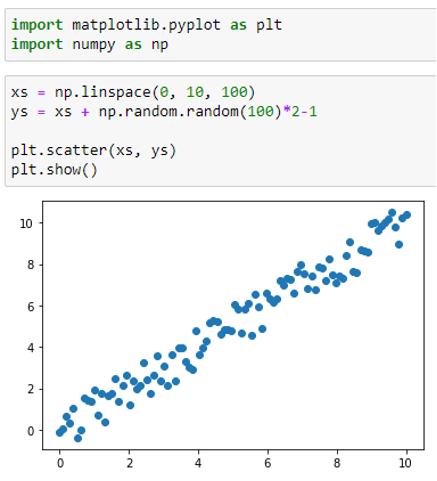

2. На одном из этих датасетов обучить модель линейной регрессии

3. Создать датасет с шумом в данных, например

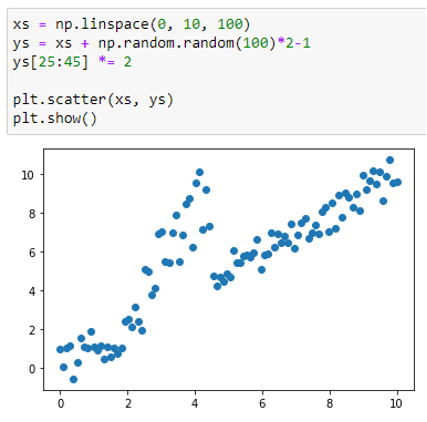

4. Провести тестирование работы модели на разных датасетах с использованием pytest, анализируя качество предсказания, обнаружить проблему на датасете с шумами.

*Критерии:* данное задание необходимо полностью выполнить в виде jupyter ноутбука и предоставить его на проверку.

*Подсказка:* вы можете записать содержимое ячейки jupyter ноутбука в отдельный файл с помощью команды

%%writefile”имя файла”

А также можете выполнить любую linux команду прямо из ячейки jupyter ноутбука, с помощью синтаксиса

! “имя команды”

**Решение задачи**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

# Создаем каталог lab5 (если его нет)
os.makedirs('lab5', exist_ok=True)
print("Каталог lab5 готов")

Каталог lab5 готов


In [6]:
# Генерация трёх «качественных» датасетов (чистых)
# Все датасеты имеют линейную зависимость y = x + небольшой шум

np.random.seed(42)  # для воспроизводимости

# Датасет 1: стандартный шум (0–10)
xs1 = np.linspace(0, 10, 100)
ys1 = xs1 + np.random.normal(0, 0.5, size=100)
df1 = pd.DataFrame({'x': xs1, 'y': ys1})
df1.to_csv('lab5/clean_data_1.csv', index=False)

# Датасет 2: более низкий уровень шума
xs2 = np.linspace(0, 10, 100)
ys2 = xs2 + np.random.normal(0, 0.2, size=100)
df2 = pd.DataFrame({'x': xs2, 'y': ys2})
df2.to_csv('lab5/clean_data_2.csv', index=False)

# Датасет 3: другой диапазон x, но тоже линейный
xs3 = np.linspace(-5, 5, 100)
ys3 = xs3 + np.random.normal(0, 0.3, size=100)
df3 = pd.DataFrame({'x': xs3, 'y': ys3})
df3.to_csv('lab5/clean_data_3.csv', index=False)

print("Три чистых датасета сохранены в lab5/")

Три чистых датасета сохранены в lab5/


In [7]:
# Обучение модели линейной регрессии на первом датасете
data1 = pd.read_csv('lab5/clean_data_1.csv')
X_train = data1[['x']].values
y_train = data1['y'].values

model = LinearRegression()
model.fit(X_train, y_train)

# Сохраняем модель
joblib.dump(model, 'lab5/linear_model.pkl')
print(f"Модель обучена. Коэффициенты: slope={model.coef_[0]:.3f}, intercept={model.intercept_:.3f}")

Модель обучена. Коэффициенты: slope=1.007, intercept=-0.086


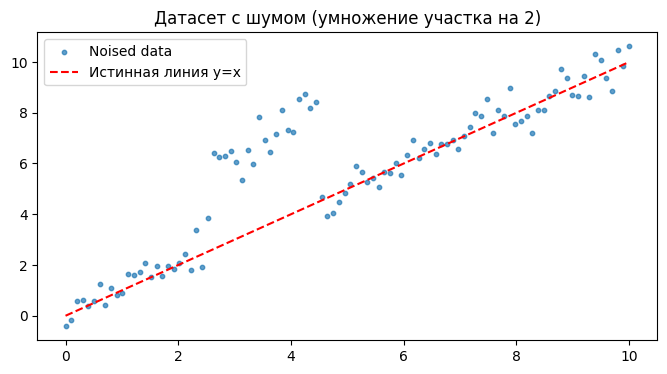

Шумный датасет сохранён в lab5/noised_data.csv


In [8]:
# Создание датасета с шумом (noised_data)
xs_noised = np.linspace(0, 10, 100)
ys_noised = xs_noised + np.random.normal(0, 0.5, size=100)
# Вносим искажения: умножаем значения y на 2 в диапазоне индексов 25:45
ys_noised[25:45] = ys_noised[25:45] * 2

df_noised = pd.DataFrame({'x': xs_noised, 'y': ys_noised})
df_noised.to_csv('lab5/noised_data.csv', index=False)

# Визуализация для проверки
plt.figure(figsize=(8,4))
plt.scatter(xs_noised, ys_noised, s=10, alpha=0.7, label='Noised data')
plt.plot(xs_noised, xs_noised, 'r--', label='Истинная линия y=x')
plt.legend()
plt.title('Датасет с шумом (умножение участка на 2)')
plt.savefig('lab5/noised_plot.png')
plt.show()
print("Шумный датасет сохранён в lab5/noised_data.csv")

In [9]:
test_code = '''import pytest
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_squared_error, r2_score

# Загружаем модель
model = joblib.load('lab5/linear_model.pkl')

@pytest.fixture(params=[
    ('lab5/clean_data_1.csv', 'clean_data_1'),
    ('lab5/clean_data_2.csv', 'clean_data_2'),
    ('lab5/clean_data_3.csv', 'clean_data_3'),
    ('lab5/noised_data.csv', 'noised_data')
])
def dataset(request):
    path, name = request.param
    data = pd.read_csv(path)
    return data, name

def test_mse_threshold(dataset):
    data, name = dataset
    X = data[['x']].values
    y_true = data['y'].values
    y_pred = model.predict(X)
    mse = mean_squared_error(y_true, y_pred)
    assert mse < 1.0, f"{name}: MSE = {mse:.3f} превышает порог 1.0"

def test_r2_threshold(dataset):
    data, name = dataset
    X = data[['x']].values
    y_true = data['y'].values
    y_pred = model.predict(X)
    r2 = r2_score(y_true, y_pred)
    assert r2 > 0.8, f"{name}: R² = {r2:.3f} ниже порога 0.8"
'''

with open('lab5/test_regression.py', 'w', encoding='utf-8') as f:
    f.write(test_code)

print("Файл тестов lab5/test_regression.py создан")


Файл тестов lab5/test_regression.py создан


In [10]:
# Убедимся, что pytest установлен
!pip install pytest -q

# Запуск тестов
!python -m pytest lab5/test_regression.py -v


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\1\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\1\OneDrive\Рабочий стол\утиль\Avto_ML
plugins: anyio-4.11.0, langsmith-0.7.12
collecting ... collected 8 items

lab5/test_regression.py::test_mse_threshold[dataset0] PASSED             [ 12%]
lab5/test_regression.py::test_mse_threshold[dataset1] PASSED             [ 25%]
lab5/test_regression.py::test_mse_threshold[dataset2] PASSED             [ 37%]
lab5/test_regression.py::test_mse_threshold[dataset3] FAILED             [ 50%]
lab5/test_regression.py::test_r2_threshold[dataset0] PASSED              [ 62%]
lab5/test_regression.py::test_r2_threshold[dataset1] PASSED              [ 75%]
lab5/test_regression.py::test_r2_threshold[dataset2] PASSED              [ 87%]
lab5/test_regression.py::test_r2_threshold[dataset3] FAILED              [100%]

